# Canada Tech Job Market & Sector Postings Analysis

Exploratory data analysis of sector job postings in Canada using the Indeed job postings index (`data/job_postings_by_sector_CA.csv`), with a focus on **Software Development**, **Data & Analytics**, and **IT Systems**.

In [25]:
%matplotlib inline
import os
os.makedirs('plots', exist_ok=True)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Environment and plotting libraries ready.")

Environment and plotting libraries ready.


## 1. Load Dataset

Load `data/job_postings_by_sector_CA.csv` and parse datetime values.

In [26]:
csv_path = 'data/job_postings_by_sector_CA.csv'
df = pd.read_csv(csv_path)
df['date'] = pd.to_datetime(df['date'])

print(f"Total records: {len(df):,}")
print(f"Date span: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
print(f"Total unique sectors: {df['display_name'].nunique()}")
df.head()

Total records: 225,694
Date span: 2020-02-01 to 2026-08-28
Total unique sectors: 47


,date,jobcountry,indeed_job_postings_index,variable,display_name
0,2020-02-01,CA,100.00,total postings,Accounting
1,2020-02-01,CA,100.00,new postings,Accounting
2,2020-02-02,CA,100.10,total postings,Accounting
3,2020-02-02,CA,100.74,new postings,Accounting
4,2020-02-03,CA,100.22,total postings,Accounting


## 2. Inspect Sectors & Variables

Examine variables (`total postings` vs `new postings`) and list all covered sectors.

In [27]:
print("Posting types / variables:", df['variable'].unique().tolist())
print("\nAll sectors in dataset:")
for sector in sorted(df['display_name'].dropna().unique()):
    print(f" - {sector}")

Posting types / variables: ['total postings', 'new postings']

All sectors in dataset:
 - Accounting
 - Administrative Assistance
 - Agriculture & Forestry
 - Architecture
 - Arts & Entertainment
 - Aviation
 - Banking & Finance
 - Beauty & Wellness
 - Childcare
 - Civil Engineering
 - Cleaning & Sanitation
 - Community & Social Service
 - Construction
 - Customer Service
 - Data & Analytics
 - Dental
 - Education & Instruction
 - Electrical Engineering
 - Food Preparation & Service
 - Hospitality & Tourism
 - Human Resources
 - IT Infrastructure, Operations & Support
 - IT Systems & Solutions
 - Industrial Engineering
 - Installation & Maintenance
 - Insurance
 - Legal
 - Logistic Support
 - Management
 - Marketing
 - Mechanical Engineering
 - Media & Communications
 - Medical Information
 - Medical Technician
 - Nursing
 - Personal Care & Home Health
 - Pharmacy
 - Physicians & Surgeons
 - Production & Manufacturing
 - Project Management
 - Retail
 - Sales
 - Scientific Research & De

## 3. Filter for Tech & Software Disciplines

Filter for sectors relevant to software engineering and data roles.

In [28]:
tech_sectors = [
    'Software Development',
    'Data & Analytics',
    'IT Systems & Solutions',
    'IT Infrastructure, Operations & Support'
]

df_tech = df[df['display_name'].isin(tech_sectors)].copy()
df_tech.head()

,date,jobcountry,indeed_job_postings_index,variable,display_name
120050,2020-02-01,CA,100.00,new postings,Data & Analytics
120051,2020-02-01,CA,100.00,total postings,Data & Analytics
120052,2020-02-02,CA,99.35,new postings,Data & Analytics
120053,2020-02-02,CA,99.83,total postings,Data & Analytics
120054,2020-02-03,CA,98.41,new postings,Data & Analytics


## 4. Trend Analysis (Total Job Postings)

The index is normalized to 100 on February 1, 2020.
- Values **> 100** indicate demand higher than pre-pandemic baseline.
- Values **< 100** indicate demand lower than pre-pandemic baseline.

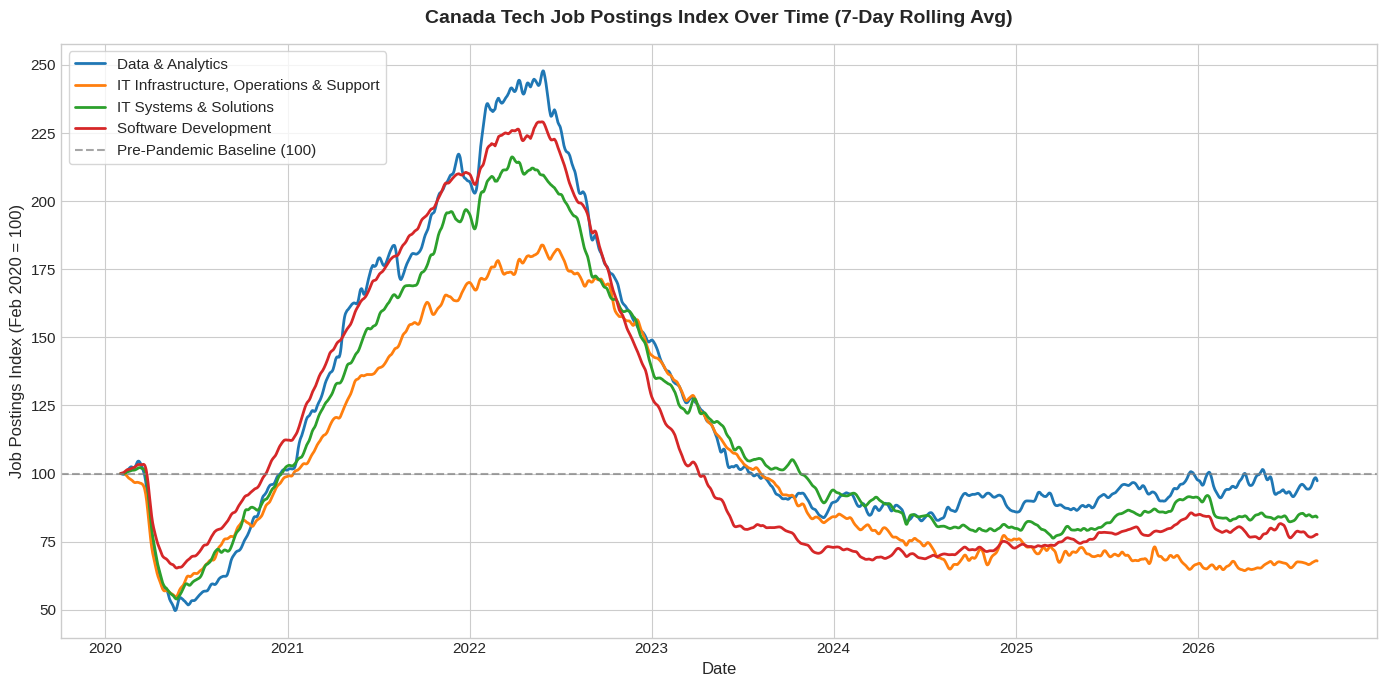

In [29]:
df_total = df_tech[df_tech['variable'] == 'total postings']
pivot_total = df_total.pivot_table(index='date', columns='display_name', values='indeed_job_postings_index')
pivot_smooth = pivot_total.rolling(window=7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 7))
for col in pivot_smooth.columns:
    ax.plot(pivot_smooth.index, pivot_smooth[col], label=col, linewidth=2)

ax.axhline(100, color='gray', linestyle='--', alpha=0.7, label='Pre-Pandemic Baseline (100)')
ax.set_title('Canada Tech Job Postings Index Over Time (7-Day Rolling Avg)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Job Postings Index (Feb 2020 = 100)', fontsize=12)
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig('plots/tech_sectors_trends.png', dpi=130, bbox_inches='tight')
plt.show()


## 5. Latest Snapshot & Ranking

Current demand snapshot for tech disciplines.

In [30]:
latest_date = df_total['date'].max()
snapshot = (
    df_total[df_total['date'] == latest_date][['display_name', 'indeed_job_postings_index']]
    .sort_values(by='indeed_job_postings_index', ascending=False)
    .reset_index(drop=True)
)
snapshot.columns = ['Tech Sector', f'Index ({latest_date.strftime("%Y-%m-%d")})']
snapshot

,Tech Sector,Index (2026-08-28)
0,Data & Analytics,94.93
1,IT Systems & Solutions,83.03
2,Software Development,77.14
3,"IT Infrastructure, Operations & Support",67.25


## 6. Explore Complementary Datasets (Metros & Provinces)

Regional demand patterns from `data/metro_job_postings_CA.csv` and `data/provincial_postings_ca.csv`.

In [31]:
df_metro = pd.read_csv('data/metro_job_postings_CA.csv')
df_metro['date'] = pd.to_datetime(df_metro['date'])
latest_metro_date = df_metro['date'].max()

print(f"Latest metro data as of: {latest_metro_date.strftime('%Y-%m-%d')}")
top_metros = (
    df_metro[df_metro['date'] == latest_metro_date]
    .sort_values(by='indeed_job_postings_index', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top_metros

Latest metro data as of: 2026-08-28


,date,Metro,indeed_job_postings_index
0,2026-08-28,"Lethbridge, AB",161.93
1,2026-08-28,"Saint John, NB",149.82
2,2026-08-28,"Saguenay, QC",149.68
3,2026-08-28,"Edmonton, AB",138.22
4,2026-08-28,"Calgary, AB",136.16
5,2026-08-28,"Saskatoon, SK",135.89
6,2026-08-28,"Trois-Rivières, QC",135.58
7,2026-08-28,"Red Deer, AB",131.47
8,2026-08-28,"Regina, SK",131.31
9,2026-08-28,"Chilliwack, BC",124.55


## 7. Correlation Analysis: Tech Sectors vs. Each Canadian Province

By merging `data/job_postings_by_sector_CA.csv` and `data/provincial_postings_ca.csv` on `date`, we measure the **co-movement** between national tech sector demand (**Software Development**, **Data & Analytics**, **IT Systems**, **IT Infrastructure**) and the overall job market across all **10 Canadian provinces**.

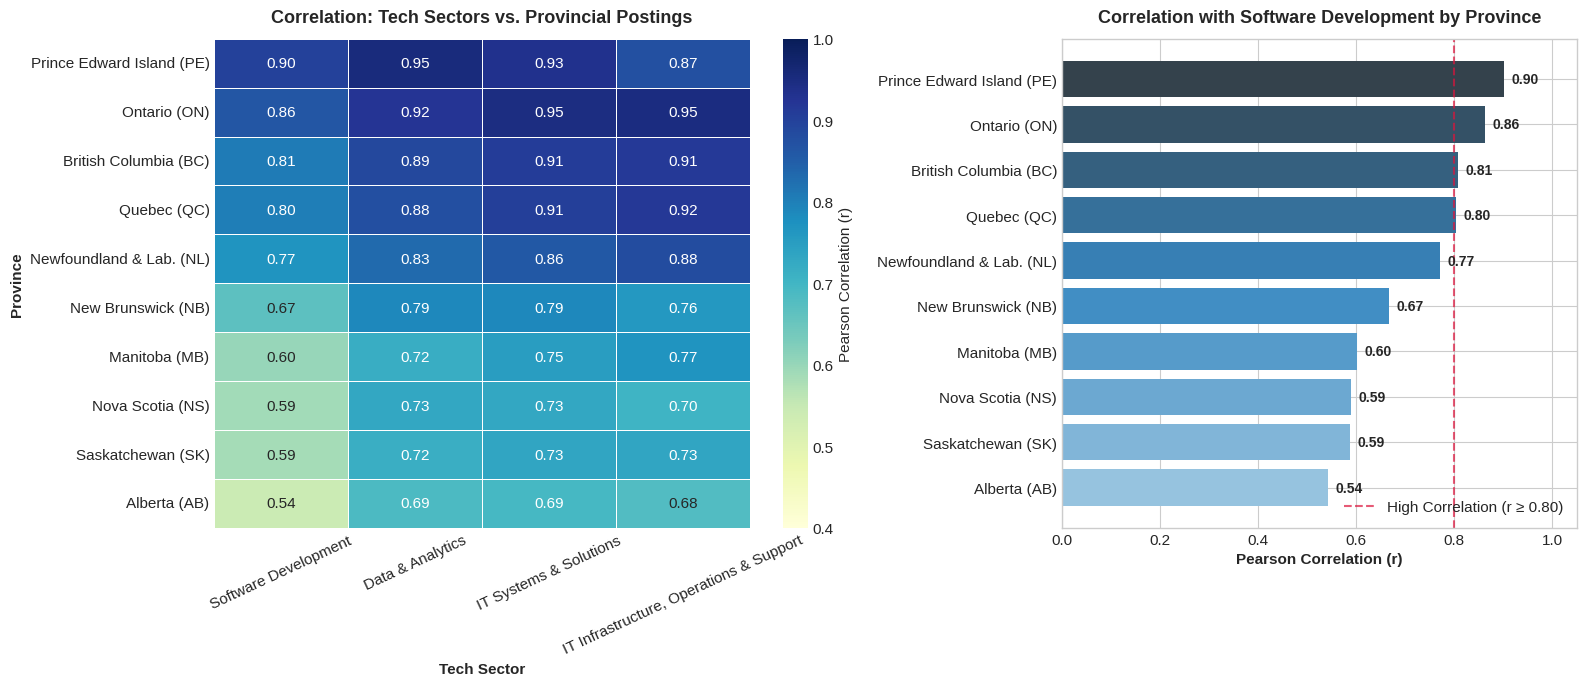

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define Tech Sectors & Load Sector Dataset (if not already loaded)
tech_sectors = [
    'Software Development',
    'Data & Analytics',
    'IT Systems & Solutions',
    'IT Infrastructure, Operations & Support'
]

if 'df' not in locals():
    df = pd.read_csv('data/job_postings_by_sector_CA.csv')
    df['date'] = pd.to_datetime(df['date'])

# 2. Load Provincial Dataset
df_prov = pd.read_csv('data/provincial_postings_ca.csv')
df_prov['date'] = pd.to_datetime(df_prov['date'])
pivot_prov = df_prov.pivot(index='date', columns='province', values='indeed_job_postings_index')

# Clean Canadian Province display mapping
prov_map = {
    'on': 'Ontario (ON)',
    'bc': 'British Columbia (BC)',
    'qc': 'Quebec (QC)',
    'ab': 'Alberta (AB)',
    'ns': 'Nova Scotia (NS)',
    'mb': 'Manitoba (MB)',
    'sk': 'Saskatchewan (SK)',
    'nb': 'New Brunswick (NB)',
    'nl': 'Newfoundland & Lab. (NL)',
    'pe': 'Prince Edward Island (PE)'
}
pivot_prov.rename(columns=prov_map, inplace=True)

# 3. Pivot Tech Sectors and Merge with Provincial Postings
sub_sector = df[(df['display_name'].isin(tech_sectors)) & (df['variable'] == 'total postings')]
pivot_tech = sub_sector.pivot(index='date', columns='display_name', values='indeed_job_postings_index')

merged_prov_tech = pd.merge(pivot_prov, pivot_tech, left_index=True, right_index=True)

# 4. Calculate Correlation Matrix (Sorted by Software Development)
corr_matrix = merged_prov_tech.corr().loc[list(prov_map.values()), tech_sectors]
corr_matrix = corr_matrix.sort_values(by='Software Development', ascending=False)

# 5. Plot: Two-Panel Figure (Heatmap + Ranked Bar Chart)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1.3, 1]})

# Left: Heatmap across all 4 tech sectors
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    vmin=0.4,
    vmax=1.0,
    cbar_kws={'label': 'Pearson Correlation (r)'},
    ax=ax1,
    linewidths=0.5
)
ax1.set_title('Correlation: Tech Sectors vs. Provincial Postings', fontsize=13, fontweight='bold', pad=12)
ax1.set_ylabel('Province', fontsize=11, fontweight='bold')
ax1.set_xlabel('Tech Sector', fontsize=11, fontweight='bold')
ax1.tick_params(axis='x', rotation=25)

# Right: Ranked Bar Chart for Software Development specifically
soft_corr = corr_matrix['Software Development'].sort_values(ascending=True)
palette = sns.color_palette('Blues_d', len(soft_corr))
bars = ax2.barh(soft_corr.index, soft_corr.values, color=palette)
ax2.set_xlim(0, 1.05)
ax2.set_title('Correlation with Software Development by Province', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Pearson Correlation (r)', fontsize=11, fontweight='bold')
ax2.axvline(0.80, color='crimson', linestyle='--', alpha=0.7, label='High Correlation (r ≥ 0.80)')
ax2.legend(loc='lower right')

for bar in bars:
    w = bar.get_width()
    ax2.text(w + 0.015, bar.get_y() + bar.get_height()/2, f'{w:.2f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/tech_province_correlation.png', dpi=130, bbox_inches='tight')
plt.show()


## 8. Hiring Velocity Tracking: Fresh Openings vs. Stale Job Postings

### Concept:
- **`total postings` (The Stock)**: All active listings on Indeed on that day (including stale or unclosed roles posted weeks ago).
- **`new postings` (The Flow)**: Only job listings published within the **last 7 days**.
- **Velocity Ratio ($\text{VR}$)**:
  $$\text{Velocity Ratio} = \frac{\text{New Postings Index}}{\text{Total Postings Index}}$$
  - $\mathbf{VR > 1.0}$ (Green Zone): **Expansion & Urgency** — fresh requisitions entering faster than old ones age out.
  - $\mathbf{VR < 1.0}$ (Red/Amber Zone): **Sluggish Inflow** — new openings slow down; existing listings linger, creating a higher share of stale or "ghost" postings.
  - $\mathbf{VR \ll 1.0}$ (e.g. 0.52 in April 2020): **Hiring Freeze** — new postings dry up instantly before old listings expire.

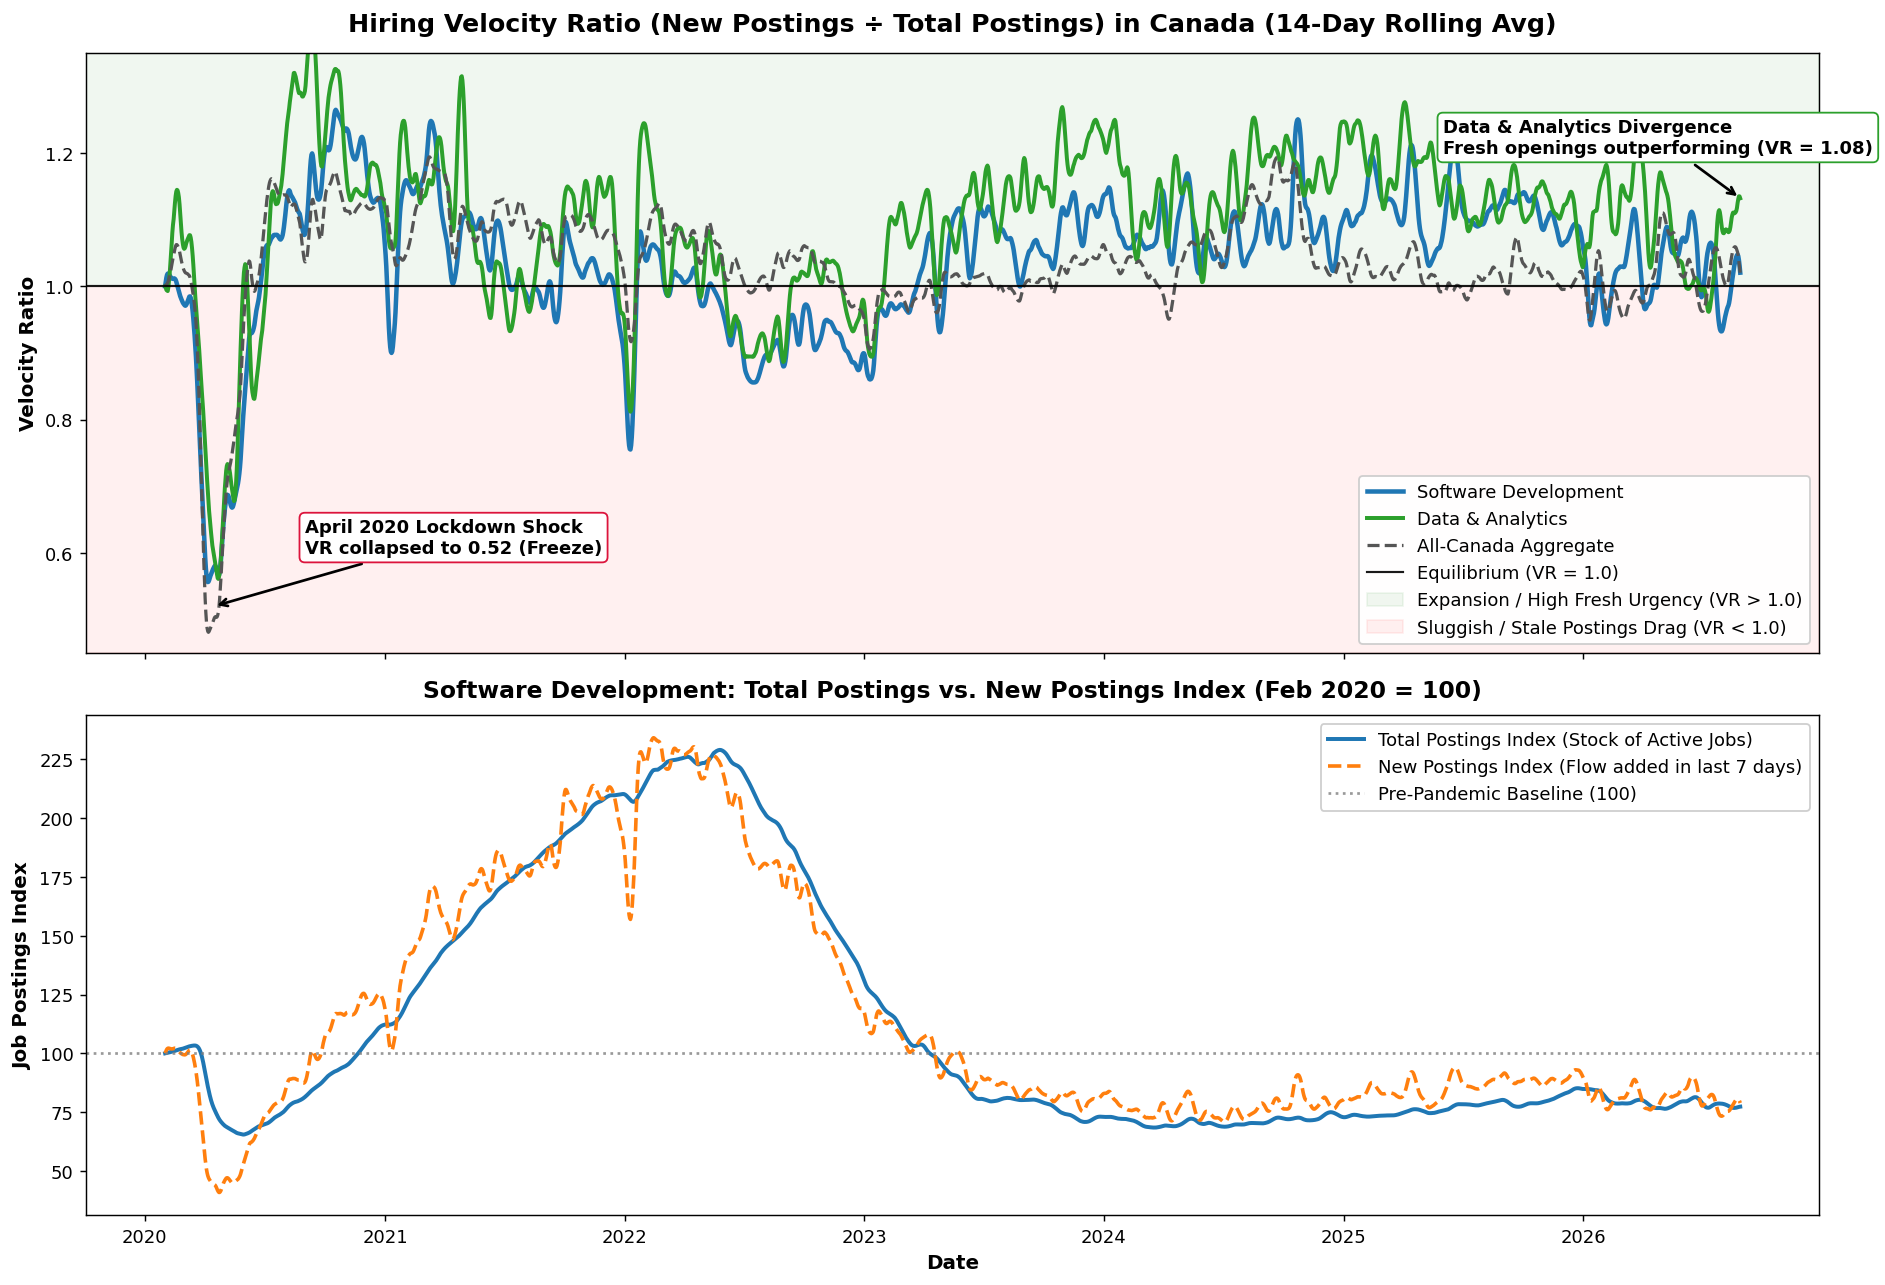

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Sector & National Aggregate Datasets
df_sector = pd.read_csv('data/job_postings_by_sector_CA.csv')
df_sector['date'] = pd.to_datetime(df_sector['date'])

df_agg = pd.read_csv('data/aggregate_job_postings_CA.csv')
df_agg['date'] = pd.to_datetime(df_agg['date'])

# 2. Calculate Velocity Ratio for Software Development
soft_df = df_sector[df_sector['display_name'] == 'Software Development']
pivot_soft = soft_df.pivot(index='date', columns='variable', values='indeed_job_postings_index')
pivot_soft['Velocity_Ratio'] = pivot_soft['new postings'] / pivot_soft['total postings']

# 3. Calculate Velocity Ratio for Data & Analytics
data_df = df_sector[df_sector['display_name'] == 'Data & Analytics']
pivot_data = data_df.pivot(index='date', columns='variable', values='indeed_job_postings_index')
pivot_data['Velocity_Ratio'] = pivot_data['new postings'] / pivot_data['total postings']

# 4. Calculate Velocity Ratio for All-Canada Aggregate Economy
pivot_agg = df_agg.pivot(index='date', columns='variable', values='indeed_job_postings_index_SA')
pivot_agg['Velocity_Ratio'] = pivot_agg['new postings'] / pivot_agg['total postings']

# 14-day rolling averages for smooth trend visibility
roll_soft = pivot_soft['Velocity_Ratio'].rolling(14, min_periods=1).mean()
roll_data = pivot_data['Velocity_Ratio'].rolling(14, min_periods=1).mean()
roll_agg = pivot_agg['Velocity_Ratio'].rolling(14, min_periods=1).mean()

# 5. Plot Two-Panel Velocity Figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [1.2, 1]})

# --- Panel 1: Velocity Ratio Over Time ---
ax1.plot(roll_soft.index, roll_soft, label='Software Development', color='#1f77b4', linewidth=2.5)
ax1.plot(roll_data.index, roll_data, label='Data & Analytics', color='#2ca02c', linewidth=2.2)
ax1.plot(roll_agg.index, roll_agg, label='All-Canada Aggregate', color='#555555', linewidth=1.8, linestyle='--')
ax1.axhline(1.0, color='black', linestyle='-', linewidth=1.2, alpha=0.9, label='Equilibrium (VR = 1.0)')

# Shaded condition zones
ax1.axhspan(1.0, 1.35, color='green', alpha=0.06, label='Expansion / High Fresh Urgency (VR > 1.0)')
ax1.axhspan(0.45, 1.0, color='red', alpha=0.06, label='Sluggish / Stale Postings Drag (VR < 1.0)')

# Milestone annotations
ax1.annotate('April 2020 Lockdown Shock\nVR collapsed to 0.52 (Freeze)',
             xy=(pd.to_datetime('2020-04-15'), 0.52),
             xytext=(pd.to_datetime('2020-09-01'), 0.60),
             arrowprops=dict(facecolor='crimson', arrowstyle='->', lw=1.5),
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='crimson', lw=1))

ax1.annotate('Data & Analytics Divergence\nFresh openings outperforming (VR = 1.08)',
             xy=(roll_data.index[-1], roll_data.iloc[-1]),
             xytext=(pd.to_datetime('2025-06-01'), 1.20),
             arrowprops=dict(facecolor='#2ca02c', arrowstyle='->', lw=1.5),
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#2ca02c', lw=1))

ax1.set_title('Hiring Velocity Ratio (New Postings ÷ Total Postings) in Canada (14-Day Rolling Avg)', fontsize=14, fontweight='bold', pad=12)
ax1.set_ylabel('Velocity Ratio', fontsize=11, fontweight='bold')
ax1.set_ylim(0.45, 1.35)
ax1.legend(loc='lower right', frameon=True, framealpha=0.95)

# --- Panel 2: Software Dev Stock vs Flow Raw Indices ---
soft_tot_smooth = pivot_soft['total postings'].rolling(14, min_periods=1).mean()
soft_new_smooth = pivot_soft['new postings'].rolling(14, min_periods=1).mean()

ax2.plot(soft_tot_smooth.index, soft_tot_smooth, label='Total Postings Index (Stock of Active Jobs)', color='#1f77b4', linewidth=2.2)
ax2.plot(soft_new_smooth.index, soft_new_smooth, label='New Postings Index (Flow added in last 7 days)', color='#ff7f0e', linewidth=2.0, linestyle='--')
ax2.axhline(100, color='gray', linestyle=':', alpha=0.8, label='Pre-Pandemic Baseline (100)')

ax2.set_title('Software Development: Total Postings vs. New Postings Index (Feb 2020 = 100)', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
ax2.set_ylabel('Job Postings Index', fontsize=11, fontweight='bold')
ax2.legend(loc='upper right', frameon=True, framealpha=0.95)

plt.tight_layout()
plt.savefig('plots/hiring_velocity_tracking.png', dpi=130, bbox_inches='tight')
plt.show()


## 9. Comprehensive Tech & STEM Industry Velocity Breakdown

Comparing **Hiring Velocity (New Postings Index ÷ Total Postings Index)** across all core tech, IT, and engineering disciplines in Canada.

- **$\mathbf{VR > 1.0}$ (Green)**: Fresh hiring urgency outperforming existing stock (companies actively recruiting).
- **$\mathbf{VR < 1.0}$ (Orange)**: Inflow of fresh requisitions has slowed; higher share of older/stale postings.

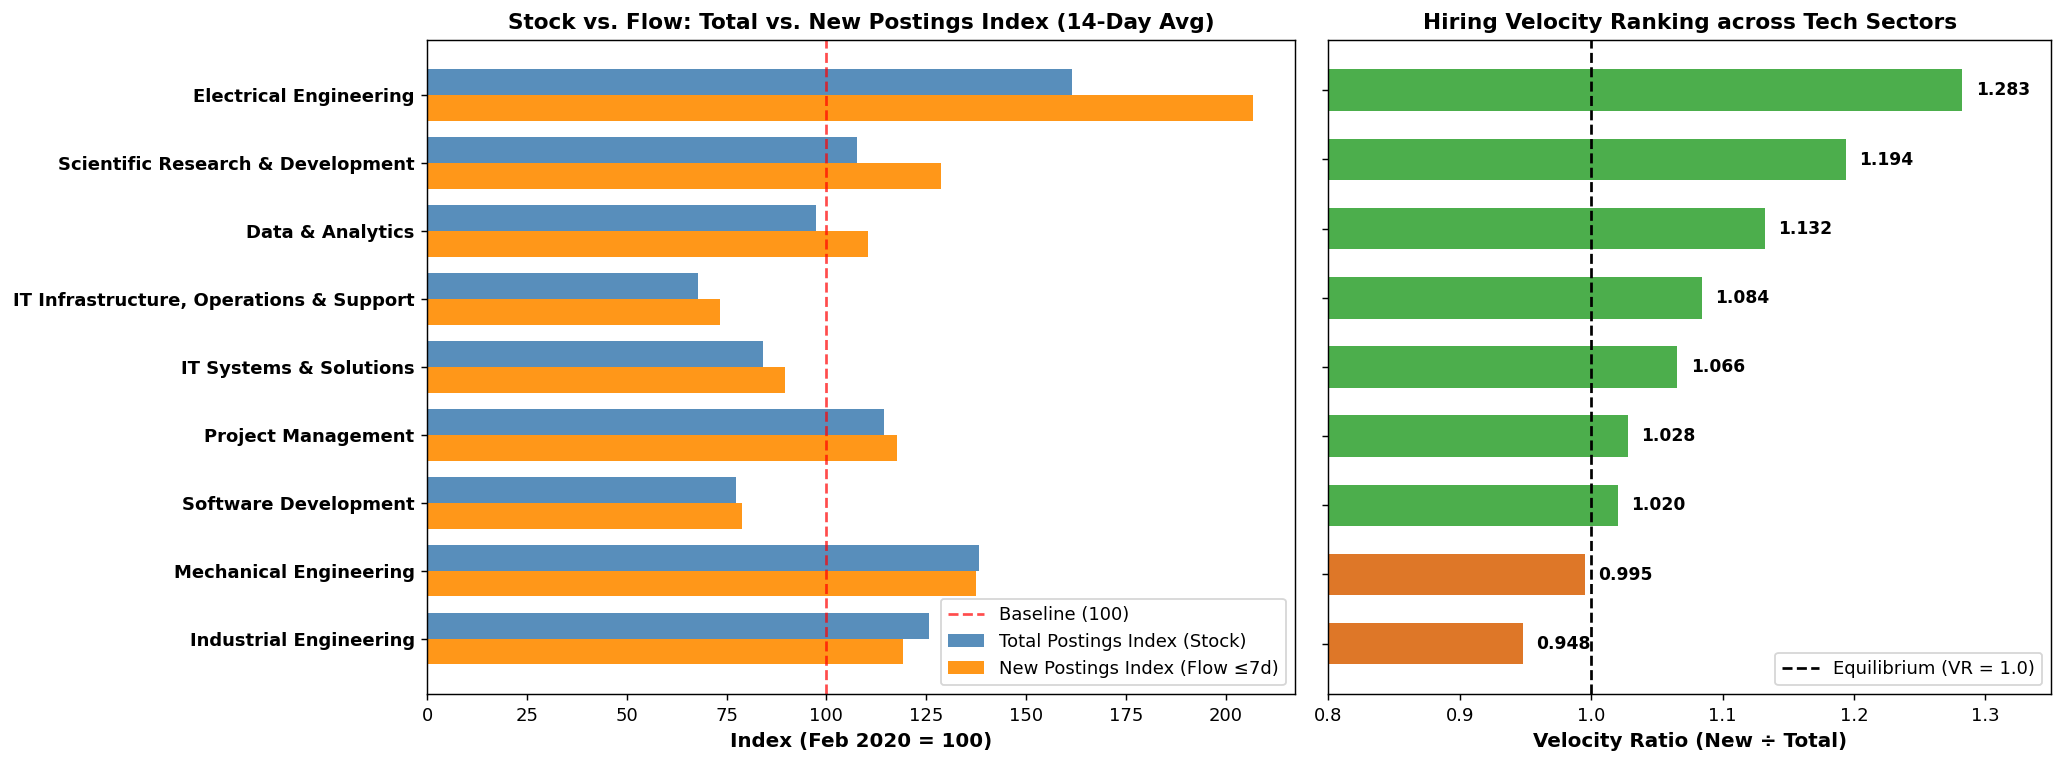

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Sector Dataset
df_sector = pd.read_csv('data/job_postings_by_sector_CA.csv')
df_sector['date'] = pd.to_datetime(df_sector['date'])

latest_date = df_sector['date'].max()
pivot_all = df_sector.pivot_table(index=['display_name', 'date'], columns='variable', values='indeed_job_postings_index').reset_index()
pivot_all['Velocity_Ratio'] = pivot_all['new postings'] / pivot_all['total postings']

# 14-day rolling smoothing
pivot_all['VR_14d'] = pivot_all.groupby('display_name')['Velocity_Ratio'].transform(lambda x: x.rolling(14, min_periods=1).mean())
pivot_all['New_14d'] = pivot_all.groupby('display_name')['new postings'].transform(lambda x: x.rolling(14, min_periods=1).mean())
pivot_all['Tot_14d'] = pivot_all.groupby('display_name')['total postings'].transform(lambda x: x.rolling(14, min_periods=1).mean())

latest_snap = pivot_all[pivot_all['date'] == latest_date].copy()

all_tech = [
    'Scientific Research & Development',
    'Data & Analytics',
    'IT Systems & Solutions',
    'Project Management',
    'Mechanical Engineering',
    'IT Infrastructure, Operations & Support',
    'Software Development',
    'Electrical Engineering',
    'Industrial Engineering'
]

tech_df = latest_snap[latest_snap['display_name'].isin(all_tech)].sort_values(by='VR_14d', ascending=True)

# 2. Plotting Comparison Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5), gridspec_kw={'width_ratios': [1.2, 1]})

y_pos = np.arange(len(tech_df))
bar_height = 0.38

# Panel 1: Stock vs. Flow Indices
ax1.barh(y_pos + bar_height/2, tech_df['Tot_14d'], height=bar_height, label='Total Postings Index (Stock)', color='#4682b4', alpha=0.9)
ax1.barh(y_pos - bar_height/2, tech_df['New_14d'], height=bar_height, label='New Postings Index (Flow ≤7d)', color='#ff8c00', alpha=0.9)
ax1.axvline(100, color='red', linestyle='--', alpha=0.7, label='Pre-Pandemic Baseline (100)')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(tech_df['display_name'], fontsize=10, fontweight='bold')
ax1.set_xlabel('Index (Feb 2020 = 100)', fontsize=11, fontweight='bold')
ax1.set_title('Stock vs. Flow: Total vs. New Postings Index (14-Day Avg)', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right', frameon=True)

# Panel 2: Velocity Ratio Ranking
colors = ['#2ca02c' if vr >= 1.0 else '#d95f02' for vr in tech_df['VR_14d']]
bars = ax2.barh(y_pos, tech_df['VR_14d'], color=colors, height=0.6, alpha=0.85)
ax2.axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='Equilibrium (VR = 1.0)')
ax2.set_yticks(y_pos)
ax2.set_yticklabels([])
ax2.set_xlim(0.8, 1.35)
ax2.set_xlabel('Velocity Ratio (New ÷ Total)', fontsize=11, fontweight='bold')
ax2.set_title('Hiring Velocity Ranking across Tech Sectors', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', frameon=True)

for bar in bars:
    w = bar.get_width()
    ax2.text(w + 0.01, bar.get_y() + bar.get_height()/2, f'{w:.3f}', va='center', fontsize=9.5, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/tech_industry_velocity_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

# Display Summary Table
table_summary = tech_df[['display_name', 'Tot_14d', 'New_14d', 'VR_14d']].sort_values(by='VR_14d', ascending=False)
table_summary.columns = ['Tech / STEM Sector', 'Total Postings Index (14d)', 'New Postings Index (14d)', 'Velocity Ratio (14d)']
table_summary.reset_index(drop=True)
